<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/03_klasican_ml_blagoje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Klasičan ML: Random Forest (Blagoje)

Klasifikacija likova iz crtaća *Tom i Džeri* u 4 klase: **tom**, **jerry**,
**both** (oba lika), **neither** (nijedan).

Ovo je **klasičan ML** model (**Random Forest**). Radi nad **ručno dizajniranim
osobinama** (HOG + histogrami boja, ukupno **1860** po slici), koje su izvučene iz
slika i snimljene u `features_hog_color.npy`. Koristi **istu podelu**
(`data_split.csv`) kao svi ostali modeli — radi poštenog poređenja.

- **Osobine:** HOG (oblici/ivice) + histogrami boja
- **Model:** Random Forest (`class_weight='balanced'` zbog neizbalansiranih klasa)
- **Izbor modela:** na **validacionom** skupu, po **macro-F1**
- **Test skup:** ne dira se ovde — evaluira se jednom, na kraju, za sve modele

In [1]:
!git clone https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification repo
!cp repo/features_hog_color.npy repo/data_split.csv .
!ls -la features_hog_color.npy data_split.csv

Cloning into 'repo'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 108 (delta 6), reused 4 (delta 2), pack-reused 92 (from 2)
Receiving objects: 100% (108/108), 215.63 MiB | 28.32 MiB/s, done.
Resolving deltas: 100% (46/46), done.
-rw-r--r-- 1 root root   159235 Sep  1 11:07 data_split.csv
-rw-r--r-- 1 root root 40756448 Sep  1 11:07 features_hog_color.npy


In [2]:
import numpy as np
import pandas as pd

X = np.load('features_hog_color.npy')      # matrica osobina, isti redosled kao data_split.csv
split_df = pd.read_csv('data_split.csv')    # kolone: filename, tom, jerry, class, split

print('X shape:', X.shape)                  # ocekujemo (5478, 1860)
print('split_df shape:', split_df.shape)

assert X.shape[0] == split_df.shape[0], 'Broj redova se ne poklapa!'

y = split_df['class'].values

train_mask = split_df['split'].values == 'train'
val_mask   = split_df['split'].values == 'val'
test_mask  = split_df['split'].values == 'test'

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print('train:', X_train.shape, '| val:', X_val.shape, '| test:', X_test.shape)

X shape: (5478, 1860)
split_df shape: (5478, 5)
train: (3755, 1860) | val: (847, 1860) | test: (844, 1860)


In [4]:
print(split_df['split'].value_counts())

split
train       3755
val          847
test         844
excluded      32
Name: count, dtype: int64


Val accuracy: 0.536
Val macro-F1: 0.4486

              precision    recall  f1-score   support

        both       0.80      0.34      0.48       115
       jerry       0.63      0.08      0.15       201
     neither       0.40      0.54      0.46       218
         tom       0.59      0.89      0.71       313

    accuracy                           0.54       847
   macro avg       0.60      0.46      0.45       847
weighted avg       0.58      0.54      0.48       847



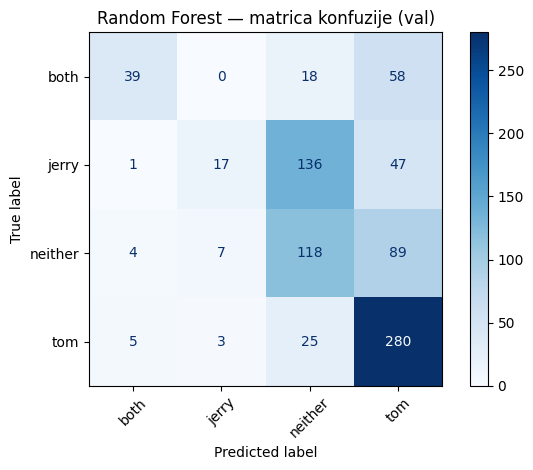

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1) napravi model
rf = RandomForestClassifier(
    n_estimators=300,          # broj stabala u "sumi"
    class_weight='balanced',   # zbog neizbalansiranih klasa
    random_state=42,           # ponovljivost (isti rezultat pri svakom pokretanju)
    n_jobs=-1)                 # koristi sva jezgra procesora (brze)

# 2) treniraj na TRAIN skupu (Random Forest-u NE treba StandardScaler)
rf.fit(X_train, y_train)

# 3) predvidi na VAL skupu (test se ne dira do kraja)
val_pred = rf.predict(X_val)

# 4) mere
print('Val accuracy:', round(accuracy_score(y_val, val_pred), 4))
print('Val macro-F1:', round(f1_score(y_val, val_pred, average='macro'), 4))
print()
print(classification_report(y_val, val_pred))

# 5) matrica konfuzije
labels = sorted(np.unique(y))
cm = confusion_matrix(y_val, val_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap='Blues', xticks_rotation=45)
plt.title('Random Forest — matrica konfuzije (val)')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import f1_score

# probamo par podesavanja i biramo najbolje po macro-F1 na VAL skupu
kandidati = [
    dict(n_estimators=300, max_depth=None, min_samples_leaf=1),  # trenutni
    dict(n_estimators=600, max_depth=None, min_samples_leaf=1),
    dict(n_estimators=600, max_depth=30,   min_samples_leaf=1),
    dict(n_estimators=600, max_depth=None, min_samples_leaf=2),
    dict(n_estimators=800, max_depth=None, min_samples_leaf=1),
]

najbolji_f1, najbolji_par, najbolji_model = -1, None, None
for p in kandidati:
    m = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **p)
    m.fit(X_train, y_train)
    f1 = f1_score(y_val, m.predict(X_val), average='macro')
    print(p, '-> val macro-F1:', round(f1, 4))
    if f1 > najbolji_f1:
        najbolji_f1, najbolji_par, najbolji_model = f1, p, m

print('\nNAJBOLJI:', najbolji_par, '| val macro-F1:', round(najbolji_f1, 4))

{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4486
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4556
{'n_estimators': 600, 'max_depth': 30, 'min_samples_leaf': 1} -> val macro-F1: 0.4538
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 2} -> val macro-F1: 0.4533
{'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4471

NAJBOLJI: {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} | val macro-F1: 0.4556


In [7]:
from sklearn.metrics import f1_score

# probamo par podesavanja i biramo najbolje po macro-F1 na VAL skupu
kandidati = [
    dict(n_estimators=300, max_depth=None, min_samples_leaf=1),  # trenutni
    dict(n_estimators=600, max_depth=None, min_samples_leaf=1),
    dict(n_estimators=600, max_depth=30,   min_samples_leaf=1),
    dict(n_estimators=600, max_depth=None, min_samples_leaf=2),
    dict(n_estimators=800, max_depth=None, min_samples_leaf=1),
]

najbolji_f1, najbolji_par, najbolji_model = -1, None, None
for p in kandidati:
    m = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **p)
    m.fit(X_train, y_train)
    f1 = f1_score(y_val, m.predict(X_val), average='macro')
    print(p, '-> val macro-F1:', round(f1, 4))
    if f1 > najbolji_f1:
        najbolji_f1, najbolji_par, najbolji_model = f1, p, m

print('\nNAJBOLJI:', najbolji_par, '| val macro-F1:', round(najbolji_f1, 4))

{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4486
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4556
{'n_estimators': 600, 'max_depth': 30, 'min_samples_leaf': 1} -> val macro-F1: 0.4538
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 2} -> val macro-F1: 0.4533
{'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4471

NAJBOLJI: {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} | val macro-F1: 0.4556


Val accuracy: 0.536
Val macro-F1: 0.4533

              precision    recall  f1-score   support

        both       0.80      0.38      0.52       115
       jerry       0.61      0.07      0.12       201
     neither       0.40      0.56      0.46       218
         tom       0.59      0.88      0.71       313

    accuracy                           0.54       847
   macro avg       0.60      0.47      0.45       847
weighted avg       0.57      0.54      0.48       847



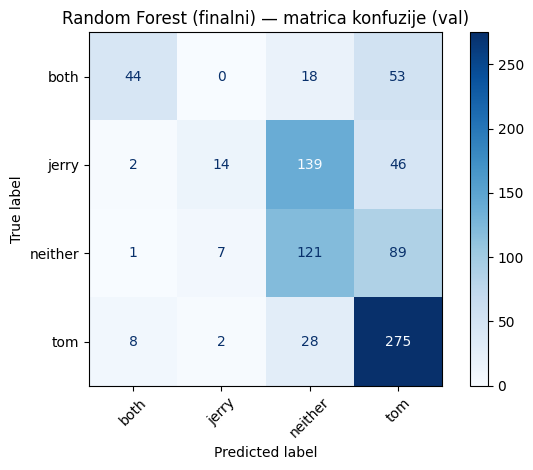

In [8]:
# Finalni Random Forest (najbolje podesavanje nadjeno na val skupu)
rf_final = RandomForestClassifier(
    n_estimators=600, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

val_pred = rf_final.predict(X_val)
print('Val accuracy:', round(accuracy_score(y_val, val_pred), 4))
print('Val macro-F1:', round(f1_score(y_val, val_pred, average='macro'), 4))
print()
print(classification_report(y_val, val_pred))

labels = sorted(np.unique(y))
cm = confusion_matrix(y_val, val_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap='Blues', xticks_rotation=45)
plt.title('Random Forest (finalni) — matrica konfuzije (val)')
plt.tight_layout(); plt.show()


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Deljena funkcija za evaluaciju — ISTA u sva 4 notebook-a (02, 03, 04, 05)
def evaluate_on_test(y_true, y_pred, model_name, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} — TEST rezultati ===")
    print(f"Accuracy: {acc:.4f}   Macro-F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predikcija'); plt.ylabel('Stvarna klasa')
    plt.title(f'{model_name} — matrica konfuzije (TEST)')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'macro_f1': macro_f1}

=== Random Forest — TEST rezultati ===
Accuracy: 0.5047   Macro-F1: 0.4223

              precision    recall  f1-score   support

         tom       0.51      0.83      0.63       289
       jerry       0.64      0.24      0.35       194
        both       1.00      0.13      0.23       131
     neither       0.43      0.53      0.48       230

    accuracy                           0.50       844
   macro avg       0.65      0.43      0.42       844
weighted avg       0.60      0.50      0.46       844



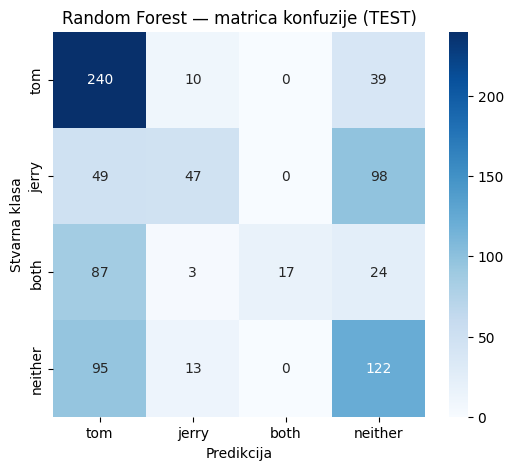

In [10]:
test_pred_rf = rf_final.predict(X_test)
class_names = ['tom', 'jerry', 'both', 'neither']
rezultat_rf = evaluate_on_test(y_test, test_pred_rf, "Random Forest", class_names)

In [11]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "rozgicblagoje@gmail.com"
!git config user.name "Blagoje"

import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(rf_final, 'models/rf_final.joblib', compress=3)

size_mb = os.path.getsize('models/rf_final.joblib') / (1024 * 1024)
print(f"models/rf_final.joblib: {size_mb:.1f} MB")

!git add models/rf_final.joblib
!git commit -m "Snimi finalni Random Forest model (rf_final) u models/ - trening bez 32 challenge slike"
!git push

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 108 (delta 6), reused 4 (delta 2), pack-reused 92 (from 2)
Receiving objects: 100% (108/108), 215.63 MiB | 28.54 MiB/s, done.
Resolving deltas: 100% (46/46), done.
Updating files: 100% (13/13), done.
/content/Tom-and-Jerry-Character-Classification
models/rf_final.joblib: 17.1 MB
[main 7a7a95e] Snimi finalni Random Forest model (rf_final) u models/
 1 file changed, 0 insertions(+), 0 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 17.04 MiB | 9.34 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classifica